# Critique of Pure Reason

One of the recurring themes of Probably Overthinking It is "Go Get the Data", which is the idea that as the ideas of Open Science have spread, it is increasingly possible to answer questions by getting and analyzing the data.

And as it gets easier to back up your opinions with data, I think it increasingly becomes an obligation. At least I find that I am increasingly impatient with people who make empirical, quantitative claims without backing them up with evidence.

As an example, let me pick on John Gray, who appeared recently on Sam Harris's podcast, Making Sense. Here's a transcript of [](https://youtu.be/OnirnAx7L-8?t=1914)

> if there is Darwinian competition among memes [...] then the fittest will not be
the best or the most rational or the most
Humane -- they'll normally be simply the
most virulent which normally is the worst
ethically speaking.
I mean what we've returned to for example now in the case
of anti-Semitism is the political
anti-Semitism of Russia in the 1890s and
Europe in the 1930s -- but rather than
coming from the Nationalist or fascist right as it did
in Russia in the 1890s or in Europe in
the 1930s and now comes from Progressive
liberalism itself that's the vehicle
that's the vehicle for this this meme
this extremely virulent, hardy, resilient
and almost all-conquering meme that
keeps reemerging.


Really?

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/examples/anes_gap.ipynb) -- but you will have to download the data yourself, because I am not allowed to redistribute it.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def make_lowess(series, frac=0.7):
    """Use LOWESS to compute a smooth line.

    series: pd.Series

    returns: pd.Series
    """
    y = series.values
    x = series.index.values

    smooth = lowess(y, x, frac=frac)
    index, data = np.transpose(smooth)

    return pd.Series(data, index=index)

In [3]:
def plot_series_lowess(series, color, plot_series=True, frac=0.7, **options):
    """Plots a series of data points and a smooth line.

    series: pd.Series
    color: string or tuple
    """
    if "label" not in options:
        options["label"] = series.name

    if plot_series or len(series) == 1:
        x = series.index
        y = series.values
        plt.plot(x, y, "o", color=color, alpha=0.3, label="_")

    if not plot_series and len(series) == 1:
        x = series.index
        y = series.values
        plt.plot(x, y, "o", color=color, alpha=0.6, label=options["label"])

    if len(series) > 1:
        smooth = make_lowess(series, frac=frac)
        smooth.plot(color=color, **options)

In [4]:
def decorate(**options):
    """Decorate the current axes.

    Call decorate with keyword arguments like
    decorate(title='Title',
             xlabel='x',
             ylabel='y')

    The keyword arguments can be any of the axis properties
    https://matplotlib.org/api/axes_api.html
    """
    ax = plt.gca()
    ax.set(**options)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels)

    plt.tight_layout()

In [5]:
def values(series):
    return series.value_counts(dropna=False).sort_index()

## Read the Data

In [6]:
from os.path import basename, exists
from pathlib import Path


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

[You can get the data here](https://electionstudies.org/data-center/anes-time-series-cumulative-data-file/) -- but you'll need to create an account.

In [7]:
df = pd.read_stata('anes_timeseries_cdf_stata_20220916.dta', convert_categoricals=False)
df.shape

(68224, 1030)

In [8]:
column_dict = {'VCF0004': 'year',
               'VCF0803': 'polviews',
               'VCF0301': 'partyid',
               'VCF0302': 'partyid3',
               'VCF0104': 'sex',
               'VCF0101': 'age',
               'VCF0009z': 'wtsamp'}

df = df.rename(columns=column_dict)

In [9]:
recode_polviews = {
    1: "Liberal",
    2: "Moderate",
    3: "Conservative",
}
df["polviews3"] = df["VCF0804"].replace(recode_polviews)
df["polviews3"].value_counts()

polviews3
Conservative    15631
Moderate        12532
Liberal         10984
9.0              9568
0.0              4193
Name: count, dtype: int64

In [10]:
df['age'].replace(0, np.nan, inplace=True)

In [11]:
def resample_rows_weighted(df, column):
    """Resamples a DataFrame using probabilities proportional to given column.

    df: DataFrame
    column: string column name to use as weights

    returns: DataFrame
    """
    weights = df[column]
    sample = df.sample(n=len(df), replace=True, weights=weights)
    return sample

In [12]:
def resample_by_year(df, column):
    """Resample rows within each year.

    df: DataFrame
    column: string name of weight variable

    returns DataFrame
    """
    grouped = df.groupby("year")
    samples = [resample_rows_weighted(group, column) for _, group in grouped]
    sample = pd.concat(samples, ignore_index=True)
    return sample

In [13]:
def percentile_rows(series_seq, ps):
    """Computes percentiles from aligned series.

    series_seq: list of sequences
    ps: cumulative probabilities

    returns: Series of x-values, NumPy array with selected rows
    """
    df = pd.concat(series_seq, axis=1).dropna()
    xs = df.index
    array = df.values.transpose()
    array = np.sort(array, axis=0)
    nrows, _ = array.shape

    ps = np.asarray(ps)
    indices = (ps * nrows).astype(int)
    rows = array[indices]
    return xs, rows

In [14]:
def plot_percentiles(series_seq, ps=None, label=None, **options):
    """Plot the low, median, and high percentiles.

    series_seq: sequence of Series
    ps: percentiles to use for low, medium and high
    label: string label for the median line
    options: options passed plt.plot and plt.fill_between
    """
    if ps is None:
        ps = [0.05, 0.5, 0.95]
    assert len(ps) == 3

    xs, rows = percentile_rows(series_seq, ps)
    low, med, high = rows
    plt.plot(xs, med, alpha=0.5, label=label, **options)
    plt.fill_between(xs, low, high, linewidth=0, alpha=0.2, **options)

In [15]:
def savefig(filename, **options):
    if 'dpi' not in options:
        options['dpi'] = 300
    plt.savefig(filename, **options)

## Analysis

> We’d also like to get your feelings about some groups in American
society. When I read the name of a group, we’d like you to rate it with
what we call a feeling thermometer. Ratings between 50 degrees-100
degrees mean that you feel favorably and warm toward the group; ratings
between 0 and 50 degrees mean that you don’t feel favorably towards the
group and that you don’t care too much for that group. If you don’t
feel particularly warm or cold toward a group you would rate them at 50
degrees. If we come to a group you don’t know much about, just tell me
and we’ll move on to the next one.

In [16]:
col = 'VCF0234'  # Christian fundamentalists
col = 'VCF0204'  # Catholics
col = 'VCF0205'  # jews
df[col].replace([98, 99], np.nan, inplace=True)

In [17]:
weighted = df.dropna(subset=['wtsamp'])
len(weighted)

68224

In [18]:
sample = resample_by_year(weighted, "wtsamp")
len(sample)

68224

In [19]:
subset = sample.dropna(subset=col)
len(subset)

28098

In [20]:
def frac40(series):
    return (series <= 40).mean() * 100

In [21]:
def compute_means(df, col='VCF0205'):
    return df.groupby('year')[col].agg(['count', 'mean', 'median', 'std', frac40])

In [22]:
summary = compute_means(subset)
summary

,count,mean,median,std,frac40
year,,,,,
1964.0,1524,61.837927,50.0,20.230954,9.776903
1966.0,1262,65.475436,60.0,21.086709,7.052298
1968.0,1497,64.037408,60.0,20.550185,7.281229
1972.0,2013,66.257824,70.0,18.733842,6.159960
1976.0,1665,57.748949,50.0,17.205158,10.210210
1988.0,1655,62.102719,60.0,19.737585,7.794562
1992.0,2144,64.699627,60.0,18.353588,4.617537
2000.0,1399,65.614725,65.0,19.805191,5.646891
2002.0,1263,62.216944,60.0,19.879960,7.284244


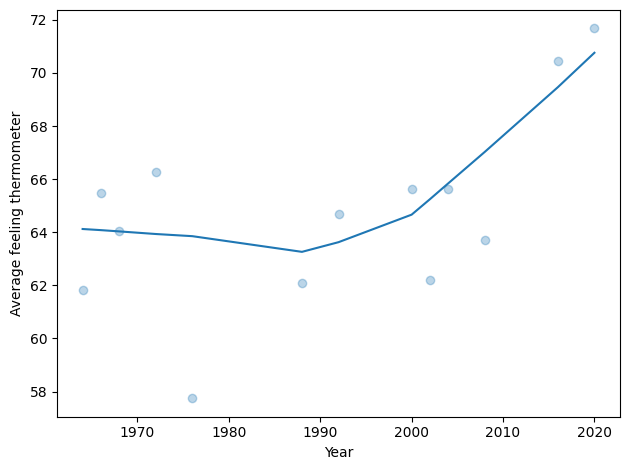

In [23]:
plot_series_lowess(summary['mean'], 'C0', label='')
decorate(xlabel='Year', ylabel='Average feeling thermometer')

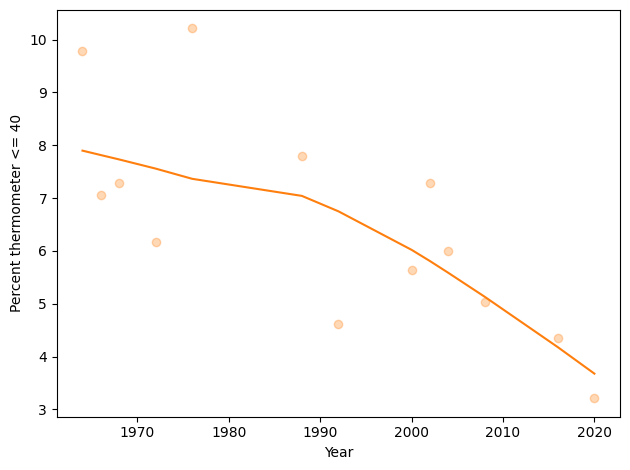

In [24]:
plot_series_lowess(summary['frac40'], 'C1', label='')
decorate(xlabel='Year', ylabel='Percent thermometer <= 40')

In [25]:
num_shades = len(summary)
colors = [plt.cm.Blues(i/num_shades) for i in range(num_shades)]
years = summary.index
color_map = dict(zip(years, colors))

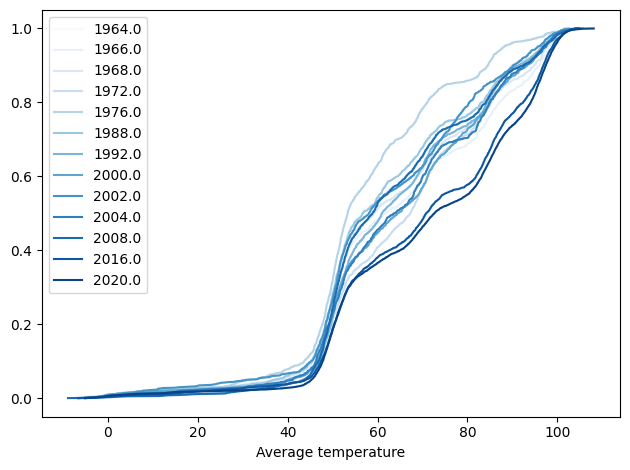

In [26]:
from empiricaldist import Cdf

for year, group in subset.groupby('year'):
    series = group[col] 
    jittered = series + np.random.normal(0, 3, size=len(series))
    cdf = Cdf.from_seq(jittered)
    cdf.plot(color=color_map[year], label=year)
    
decorate(xlabel='Average temperature')

In [27]:
polview_names = ["Conservative", "Moderate", "Liberal"]

muted = sns.color_palette("muted", 5)
polview_color_map = dict(zip(polview_names, [muted[3], muted[4], muted[0]]))
marker_map = dict(zip(polview_names, ["s", "^", "o"]))
line_map = dict(zip(polview_names, [":", "-.", "--"]))

In [28]:
def plot_by_polviews(df, col):
    table = df.pivot_table(index="year", columns="polviews3", values=col)

    columns = ["Conservative", "Moderate", "Liberal"]
    options = dict(frac=0.7, plot_series=True)

    for column in columns:
        plot_series_lowess(
            table[column],
            ls=line_map[column],
            color=polview_color_map[column],
            **options
        )

    decorate(
        xlabel="Year",
        ylabel="Average temperature",
    )

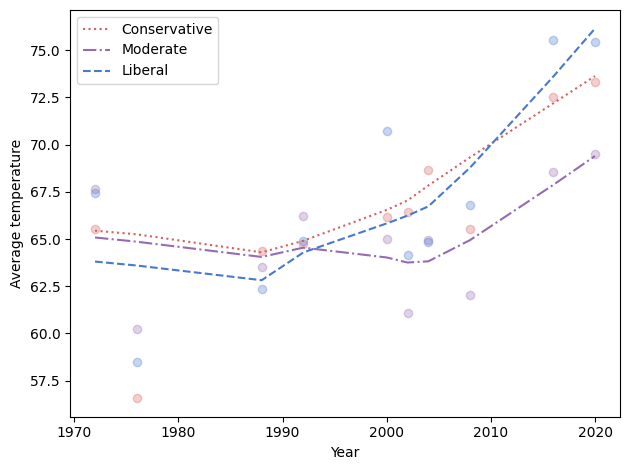

In [29]:
plot_by_polviews(subset, col)